In [9]:
%pip install pandas mysql-connector-python pyarrow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv(r'C:\Users\camil\OneDrive\Escritorio\Proyecto_final_mod2\olist_order_items_dataset.csv')
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nBasic statistics:")
print(df.describe())

Dataset shape: (112650, 7)

Column names:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

Data types:
order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object

Basic statistics:
       order_item_id          price  freight_value
count  112650.000000  112650.000000  112650.000000
mean        1.197834     120.653739      19.990320
std         0.705124     183.633928      15.806405
min         1.000000       0.850000       0.000000
25%         1.000000      39.900000      13.080000
50%         1.000000      74.990000      16.260000
75%         1.000000     134.900000      21.150000
max        21.000000    6735.000000     409.680000


In [4]:
pd.to_datetime(df['shipping_limit_date'], errors='coerce')

0        2017-09-19 09:45:35
1        2017-05-03 11:05:13
2        2018-01-18 14:48:30
3        2018-08-15 10:10:18
4        2017-02-13 13:57:51
                 ...        
112645   2018-05-02 04:11:01
112646   2018-07-20 04:31:48
112647   2017-10-30 17:14:25
112648   2017-08-21 00:04:32
112649   2018-06-12 17:10:13
Name: shipping_limit_date, Length: 112650, dtype: datetime64[us]

In [5]:
# Create Father Table: customers
father_table = df[['customer_id', 'customer_unique_id', 'customer_city', 'customer_state']].drop_duplicates()

# Create Daughter Table: customer_addresses
daughter_table = df[['customer_id', 'customer_zip_code_prefix']].drop_duplicates()

# Save to CSV files
father_table.to_csv("customers.csv", index=False)
daughter_table.to_csv("customer_addresses.csv", index=False)

print("Father table (customers):")
print(father_table.head())
print("\nDaughter table (customer_addresses):")
print(daughter_table.head())

KeyError: "None of [Index(['customer_id', 'customer_unique_id', 'customer_city', 'customer_state'], dtype='str')] are in the [columns]"

In [ ]:
CREATE TABLE customers (
    customer_id   VARCHAR(50) PRIMARY KEY,
    customer_city VARCHAR(100),
    customer_state VARCHAR(5)
);

CREATE TABLE orders (
    order_id      VARCHAR(50) PRIMARY KEY,
    customer_id   VARCHAR(50),
    order_status  VARCHAR(20),
    order_purchase_timestamp    DATETIME,
    FOREIGN KEY (customer_id) REFERENCES customers(customer_id)
);

CREATE TABLE order_items (
    order_id      VARCHAR(50) PRIMARY KEY,
    order_item_id VARCHAR(50),
    product_id    VARCHAR(50),
    seller_id     VARCHAR(50),
    shipping_limit_date DATETIME,
    price         DECIMAL(10,2),
    freight_value DECIMAL(10,2),
    FOREIGN KEY (order_id) REFERENCES orders(order_id)
);

# Ejemplo de uso (adaptar columnas a vuestro CSV):
# df_customers = pd.read_csv("olist_customers_dataset.csv")
# df_customers = df_customers[["customer_id", "customer_city", "customer_state"]]
# conn = mysql.connector.connect(**mysql_config)
# cargar_csv_en_tabla(df_customers, "customers", conn)
# conn.close()

In [ ]:
# Add this before the data processing section:
df_order_items = df_order_items.drop_duplicates(subset=['order_id', 'order_item_id'], keep='first')

In [12]:
import pandas as pd
import mysql.connector
from credenciales import mysql_config

def crear_tabla_orders(conn):
    """Crea la tabla orders si no existe"""
    cursor = conn.cursor()
    create_table_query = """
    CREATE TABLE IF NOT EXISTS orders (
        order_id VARCHAR(50) PRIMARY KEY,
        customer_id VARCHAR(50),
        order_status VARCHAR(20),
        order_purchase_timestamp DATETIME,
        order_delivered_carrier_date DATETIME,
        order_delivered_customer_date DATETIME,
        order_estimated_delivery_date DATETIME
    )
    """
    cursor.execute(create_table_query)
    conn.commit()
    cursor.close()
    print("Tabla orders creada o ya existente")

def crear_tabla_order_items(conn):
    """Crea la tabla order_items si no existe"""
    cursor = conn.cursor()
    create_table_query = """
    CREATE TABLE IF NOT EXISTS order_items (
        order_id VARCHAR(50),
        order_item_id VARCHAR(50),
        product_id VARCHAR(50),
        seller_id VARCHAR(50),
        shipping_limit_date DATETIME,
        price DECIMAL(10,2),
        freight_value DECIMAL(10,2),
        PRIMARY KEY (order_id, order_item_id),
        FOREIGN KEY (order_id) REFERENCES orders(order_id)
    )
    """
    cursor.execute(create_table_query)
    conn.commit()
    cursor.close()
    print("Tabla order_items creada o ya existente")

def cargar_olist_order_items_dataset_en_order_items(df, order_items, conn, batch=1000):
    """Inserta un DataFrame en una tabla de MySQL en lotes de `batch` filas."""
    cursor = conn.cursor()
    cols = ", ".join(df.columns)
    placeholders = ", ".join(["%s"] * len(df.columns))
    # Use INSERT IGNORE to skip duplicates
    sql = f"INSERT IGNORE INTO {order_items} ({cols}) VALUES ({placeholders})"

    filas = [tuple(None if pd.isna(v) else v for v in row)
             for row in df.itertuples(index=False, name=None)]

    for i in range(0, len(filas), batch):
        cursor.executemany(sql, filas[i:i+batch])
        conn.commit()
        print(f"  insertadas {min(i+batch, len(filas))}/{len(filas)}")
    cursor.close()

try:
    # Load and process the data
    df_order_items = pd.read_csv(r"C:\Users\camil\OneDrive\Escritorio\Proyecto_final_mod2\olist_order_items_dataset.csv")
    df_order_items = df_order_items[["order_id", "order_item_id", "product_id", "seller_id", "shipping_limit_date", "price", "freight_value"]]

    # Connect to database
    conn = mysql.connector.connect(**mysql_config)

    # Create tables first (orders before order_items)
    crear_tabla_orders(conn)
    crear_tabla_order_items(conn)

    # Call the function to insert data
    cargar_olist_order_items_dataset_en_order_items(df_order_items, "order_items", conn)

    print("Datos cargados exitosamente!")
    
except mysql.connector.Error as err:
    print(f"Error de MySQL: {err}")
except Exception as e:
    print(f"Error: {e}")
finally:
    if 'conn' in locals() and conn.is_connected():
        conn.close()
        print("Conexión cerrada")


Tabla orders creada o ya existente
Tabla order_items creada o ya existente
  insertadas 1000/112650
  insertadas 2000/112650
  insertadas 3000/112650
  insertadas 4000/112650
  insertadas 5000/112650
  insertadas 6000/112650
  insertadas 7000/112650
  insertadas 8000/112650
  insertadas 9000/112650
  insertadas 10000/112650
  insertadas 11000/112650
  insertadas 12000/112650
  insertadas 13000/112650
  insertadas 14000/112650
  insertadas 15000/112650
  insertadas 16000/112650
  insertadas 17000/112650
  insertadas 18000/112650
  insertadas 19000/112650
  insertadas 20000/112650
  insertadas 21000/112650
  insertadas 22000/112650
  insertadas 23000/112650
  insertadas 24000/112650
  insertadas 25000/112650
  insertadas 26000/112650
  insertadas 27000/112650
  insertadas 28000/112650
  insertadas 29000/112650
  insertadas 30000/112650
  insertadas 31000/112650
  insertadas 32000/112650
  insertadas 33000/112650
  insertadas 34000/112650
  insertadas 35000/112650
  insertadas 36000/11265

In [62]:
conn = mysql.connector.connect(**mysql_config)

query = """
SELECT
    o.order_id,
    o.order_purchase_timestamp as order_date,  -- Fixed: changed from order_date to order_purchase_timestamp
    o.order_status,
    c.customer_city,
    c.customer_state,
    oi.price,
    oi.freight_value
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN order_items oi ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
"""

df = pd.read_sql(query, conn)
conn.close()

df.head()


C:\Users\camil\AppData\Local\Temp\ipykernel_21520\111394347.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,order_id,order_date,order_status,customer_city,customer_state,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,2017-09-13 08:59:02,delivered,campos dos goytacazes,RJ,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,2017-04-26 10:53:06,delivered,santa fe do sul,SP,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,2018-01-14 14:33:31,delivered,para de minas,MG,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,2018-08-08 10:00:35,delivered,atibaia,SP,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,2017-02-04 13:57:51,delivered,varzea paulista,SP,199.90,18.14


In [63]:
df.to_pickle("dataset_analitico.pkl")
df = pd.read_pickle("dataset_analitico.pkl")

# Fase 5

In [15]:
query = """
SELECT
    o.order_id,
    o.order_purchase_timestamp as order_date,  -- Fixed: changed from order_date to order_purchase_timestamp
    o.order_status,
    c.customer_city,
    c.customer_state,
    oi.price,
    oi.freight_value
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN order_items oi ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
"""
df.head(5)

,order_id,order_date,order_status,customer_city,customer_state,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,2017-09-13 08:59:02,delivered,campos dos goytacazes,RJ,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,2017-04-26 10:53:06,delivered,santa fe do sul,SP,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,2018-01-14 14:33:31,delivered,para de minas,MG,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,2018-08-08 10:00:35,delivered,atibaia,SP,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,2017-02-04 13:57:51,delivered,varzea paulista,SP,199.90,18.14


# Fase 6

In [16]:
df.dtypes

order_id                     str
order_date        datetime64[us]
order_status                 str
customer_city                str
customer_state               str
price                    float64
freight_value            float64
dtype: object

In [17]:
df.isna().sum()

order_id          0
order_date        0
order_status      0
customer_city     0
customer_state    0
price             0
freight_value     0
dtype: int64

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.describe()

,order_date,price,freight_value
count,96478,96478.000000,96478.000000
mean,2018-01-01 23:29:31.939913,125.280336,20.160296
min,2016-09-15 12:16:38,0.850000,0.000000
25%,2017-09-14 09:00:23.250000,41.300000,13.300000
50%,2018-01-20 19:45:45,79.000000,16.360000
75%,2018-05-05 18:54:47,139.900000,21.200000
max,2018-08-29 15:00:37,6735.000000,409.680000
std,NaN,190.099465,15.801311


In [20]:
df.head(20)


,order_id,order_date,order_status,customer_city,customer_state,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,2017-09-13 08:59:02,delivered,campos dos goytacazes,RJ,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,2017-04-26 10:53:06,delivered,santa fe do sul,SP,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,2018-01-14 14:33:31,delivered,para de minas,MG,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,2018-08-08 10:00:35,delivered,atibaia,SP,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,2017-02-04 13:57:51,delivered,varzea paulista,SP,199.90,18.14
5,00048cc3ae777c65dbb7d2a0634bc1ea,2017-05-15 21:42:34,delivered,uberaba,MG,21.90,12.69
6,00054e8431b9d7675808bcb819fb4a32,2017-12-10 11:53:48,delivered,guararapes,SP,19.90,11.85
7,000576fe39319847cbb9d288c5617fa6,2018-07-04 12:08:27,delivered,praia grande,SP,810.00,70.75
8,0005a1a1728c9d785b8e2b08b904576c,2018-03-19 18:40:33,delivered,santos,SP,145.95,11.65
9,0005f50442cb953dcd1d21e1fb923495,2018-07-02 13:59:39,delivered,jandira,SP,53.99,11.40


# Fase 7

In [ ]:
# Here we will analyze the total number of orders by state. We will group the data by 'customer_state' and count the number of orders for each state.
orders_by_state = df.groupby('customer_state').size().reset_index(name='total_orders')
orders_by_state = orders_by_state.sort_values('total_orders', ascending=False)

print("Total number of orders by state:")
print(orders_by_state)



Total number of orders by state:
   customer_state  total_orders
25             SP         40501
18             RJ         12350
10             MG         11354
22             RS          5345
17             PR          4923
23             SC          3546
4              BA          3256
6              DF          2080
7              ES          1995
8              GO          1957
15             PE          1593
5              CE          1279
13             PA           946
12             MT           886
9              MA           717
11             MS           701
14             PB           517
16             PI           476
19             RN           474
1              AL           397
24             SE           335
26             TO           274
20             RO           243
2              AM           145
0              AC            80
3              AP            67
21             RR            41


In [29]:
%pip install matplotlib seaborn

  Using cached matplotlib-3.10.9-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.9-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl (232 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 42.8 MB/s  0:00:00
Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl (75 kB)
Using cached pillow-12.2.0-cp314-cp314-win_amd64.whl (7.2 MB)


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


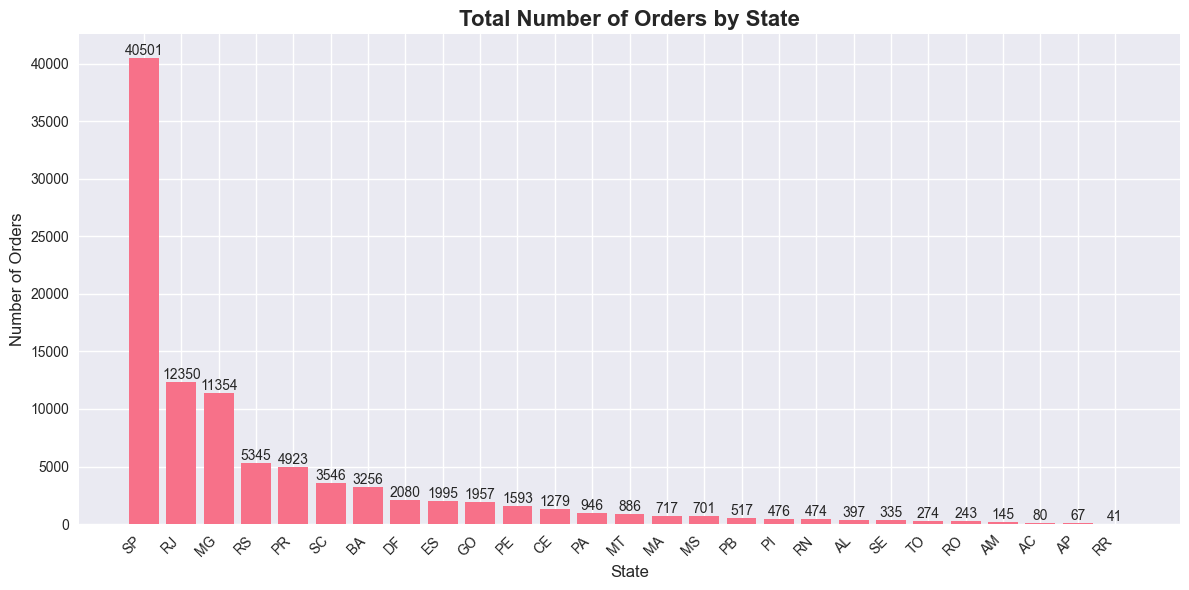

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better looking plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Create the bar chart
plt.figure(figsize=(12, 6))
bars = plt.bar(orders_by_state['customer_state'], orders_by_state['total_orders'])

# Customize the plot
plt.title('Total Number of Orders by State', fontsize=16, fontweight='bold')
plt.xlabel('State', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add value labels on bars (optional)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom')

plt.tight_layout()
plt.show()


Aquí podemos ver que estados tuvieron mayor número de ordenes totales ordenados de mayor a menor

Total sales by state (sorted by highest sales):
   customer_state       price
25             SP  4622372.76
18             RJ  1600069.39
10             MG  1426814.97
22             RS   665874.71
17             PR   605068.66
23             SC   463137.93
4              BA   447295.96
6              DF   273492.07
8              GO   254663.10
7              ES   246252.69
15             PE   237212.57
5              CE   201459.66
13             PA   163611.54
12             MT   134028.92
9              MA   109234.47
11             MS   106949.90
14             PB   104744.95
19             RN    78408.01
16             PI    77233.80
1              AL    74723.69
24             SE    51863.12
26             TO    45403.58
20             RO    43656.80
2              AM    20581.48
0              AC    14858.98
3              AP    11595.98
21             RR     6186.56

State with highest sales: SP
Total sales: R$4,622,372.76


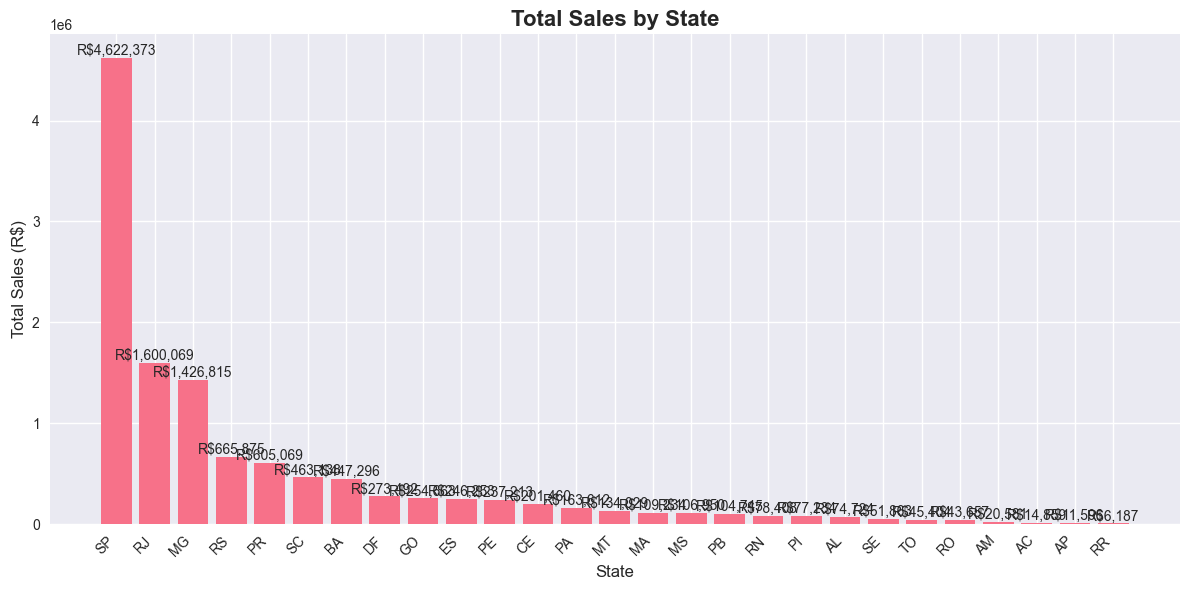

In [31]:
# Calculate total sales by state (sum of price column)
sales_by_state = df.groupby('customer_state')['price'].sum().reset_index()
sales_by_state = sales_by_state.sort_values('price', ascending=False)

print("Total sales by state (sorted by highest sales):")
print(sales_by_state)

# Find the state with highest sales
max_sales_state = sales_by_state.loc[sales_by_state['price'].idxmax()]
print(f"\nState with highest sales: {max_sales_state['customer_state']}")
print(f"Total sales: R${max_sales_state['price']:,.2f}")

# Create a bar chart for sales by state
plt.figure(figsize=(12, 6))
bars = plt.bar(sales_by_state['customer_state'], sales_by_state['price'])
plt.title('Total Sales by State', fontsize=16, fontweight='bold')
plt.xlabel('State', fontsize=12)
plt.ylabel('Total Sales (R$)', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'R${height:,.0f}',
             ha='center', va='bottom')

plt.tight_layout()
plt.show()


Y aquí podemos ver los estados que mas vendieron en dinero, igualmente ordenados de mayor a menor

Como podemos ver, hay una clara dominancia por parte de SP sobre los demás estados

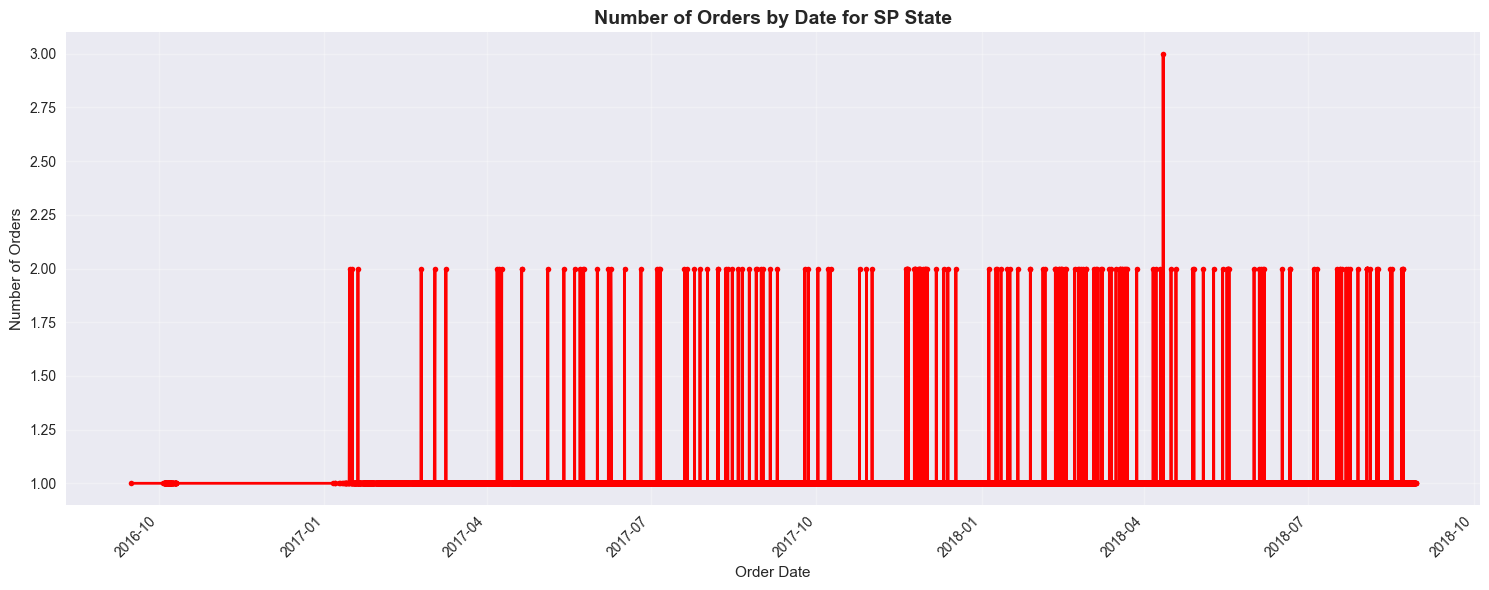

Total number of orders for SP over time:
         order_date  order_count
2016-09-15 12:16:38            1
2016-10-03 09:44:50            1
2016-10-03 22:06:03            1
2016-10-03 22:31:31            1
2016-10-04 09:06:10            1
2016-10-04 09:16:33            1
2016-10-04 09:59:03            1
2016-10-04 12:53:17            1
2016-10-04 13:15:52            1
2016-10-04 14:44:33            1
2016-10-04 15:10:15            1
2016-10-04 15:12:18            1
2016-10-04 15:44:44            1
2016-10-04 16:05:29            1
2016-10-04 16:08:52            1
2016-10-04 16:40:07            1
2016-10-04 17:08:39            1
2016-10-04 17:25:09            1
2016-10-04 18:07:24            1
2016-10-04 18:52:56            1
2016-10-04 20:41:55            1
2016-10-04 21:54:52            1
2016-10-04 22:15:11            1
2016-10-04 23:08:08            1
2016-10-04 23:39:01            1
2016-10-05 00:32:31            1
2016-10-05 11:05:52            1
2016-10-05 11:08:46            1
20

In [48]:
# Group by date and count orders for SP state
sp_orders_by_date = df[df['customer_state'] == 'SP'].groupby('order_date').size().reset_index(name='order_count')

# Sort by date ascending (oldest to newest)
sp_orders_by_date = sp_orders_by_date.sort_values('order_date')

# Create line chart
plt.figure(figsize=(15, 6))
plt.plot(sp_orders_by_date['order_date'], sp_orders_by_date['order_count'], marker='o', linewidth=2, markersize=4, color='red')
plt.title('Number of Orders by Date for SP State', fontsize=14, fontweight='bold')
plt.xlabel('Order Date')
plt.ylabel('Number of Orders')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Display the results
print("Total number of orders for SP over time:")
print(sp_orders_by_date.to_string(index=False))

# Show total count
print(f"\nTotal orders for SP: {sp_orders_by_date['order_count'].sum()}")


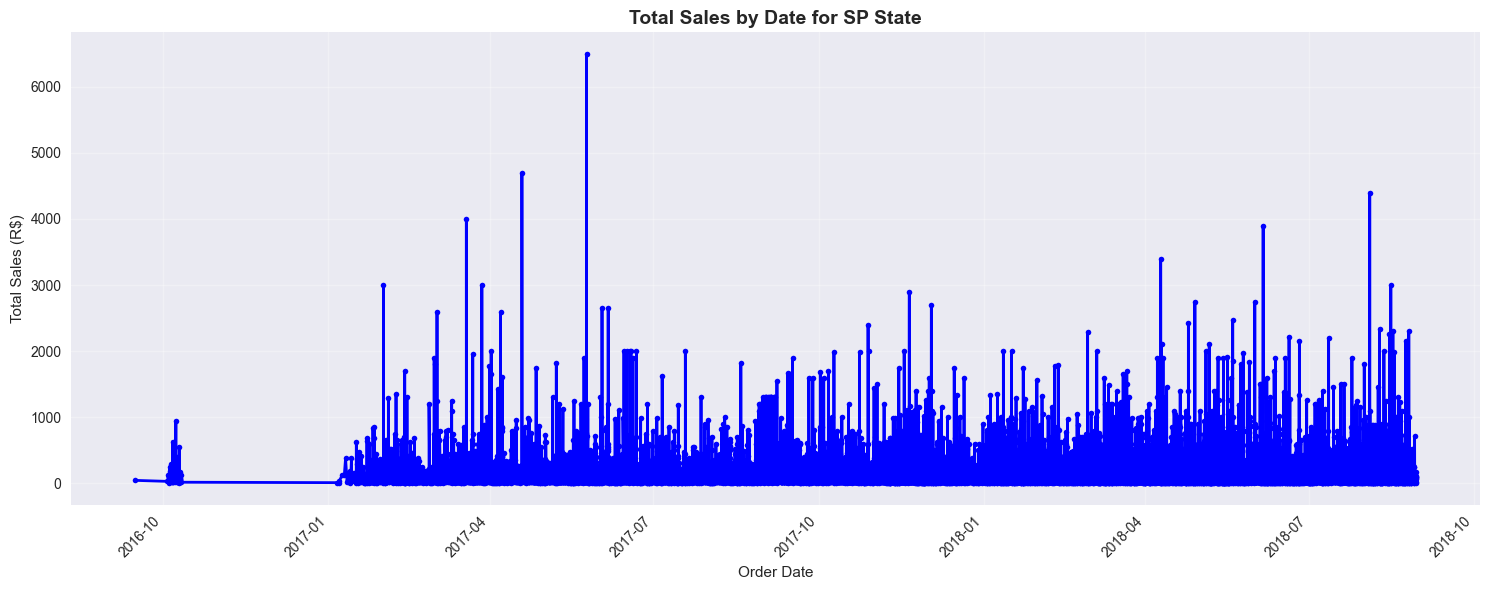

Total sales for SP over time:
         order_date   price
2016-09-15 12:16:38   44.99
2016-10-03 09:44:50   29.90
2016-10-03 22:06:03  119.90
2016-10-03 22:31:31   29.99
2016-10-04 09:06:10   49.99
2016-10-04 09:16:33   32.49
2016-10-04 09:59:03   89.90
2016-10-04 12:53:17    9.90
2016-10-04 13:15:52  128.90
2016-10-04 14:44:33  249.90
2016-10-04 15:10:15   89.90
2016-10-04 15:12:18   69.99
2016-10-04 15:44:44  109.90
2016-10-04 16:05:29   49.90
2016-10-04 16:08:52   59.90
2016-10-04 16:40:07   59.90
2016-10-04 17:08:39   57.00
2016-10-04 17:25:09  139.90
2016-10-04 18:07:24   99.90
2016-10-04 18:52:56   86.99
2016-10-04 20:41:55  149.90
2016-10-04 21:54:52   71.00
2016-10-04 22:15:11   49.90
2016-10-04 23:08:08  149.90
2016-10-04 23:39:01  179.90
2016-10-05 00:32:31   24.90
2016-10-05 11:05:52   86.99
2016-10-05 11:08:46  149.99
2016-10-05 14:49:49   29.90
2016-10-05 15:08:00  294.90
2016-10-05 17:14:27   49.99
2016-10-05 19:09:33   22.37
2016-10-05 22:39:46   22.90
2016-10-06 02:53:3

In [49]:
# Group by date and sum price for SP state
sp_sales_by_date = df[df['customer_state'] == 'SP'].groupby('order_date')['price'].sum().reset_index()

# Sort by date ascending (oldest to newest)
sp_sales_by_date = sp_sales_by_date.sort_values('order_date')

# Create line chart
plt.figure(figsize=(15, 6))
plt.plot(sp_sales_by_date['order_date'], sp_sales_by_date['price'], marker='o', linewidth=2, markersize=4, color='blue')
plt.title('Total Sales by Date for SP State', fontsize=14, fontweight='bold')
plt.xlabel('Order Date')
plt.ylabel('Total Sales (R$)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Display the results
print("Total sales for SP over time:")
print(sp_sales_by_date.to_string(index=False))

# Show total sales
print(f"\nTotal sales for SP: R${sp_sales_by_date['price'].sum():,.2f}")



Usando estas dos tablas podemos ver que el numero de pedidos no es directamente proporcional al total de ventas por fecha

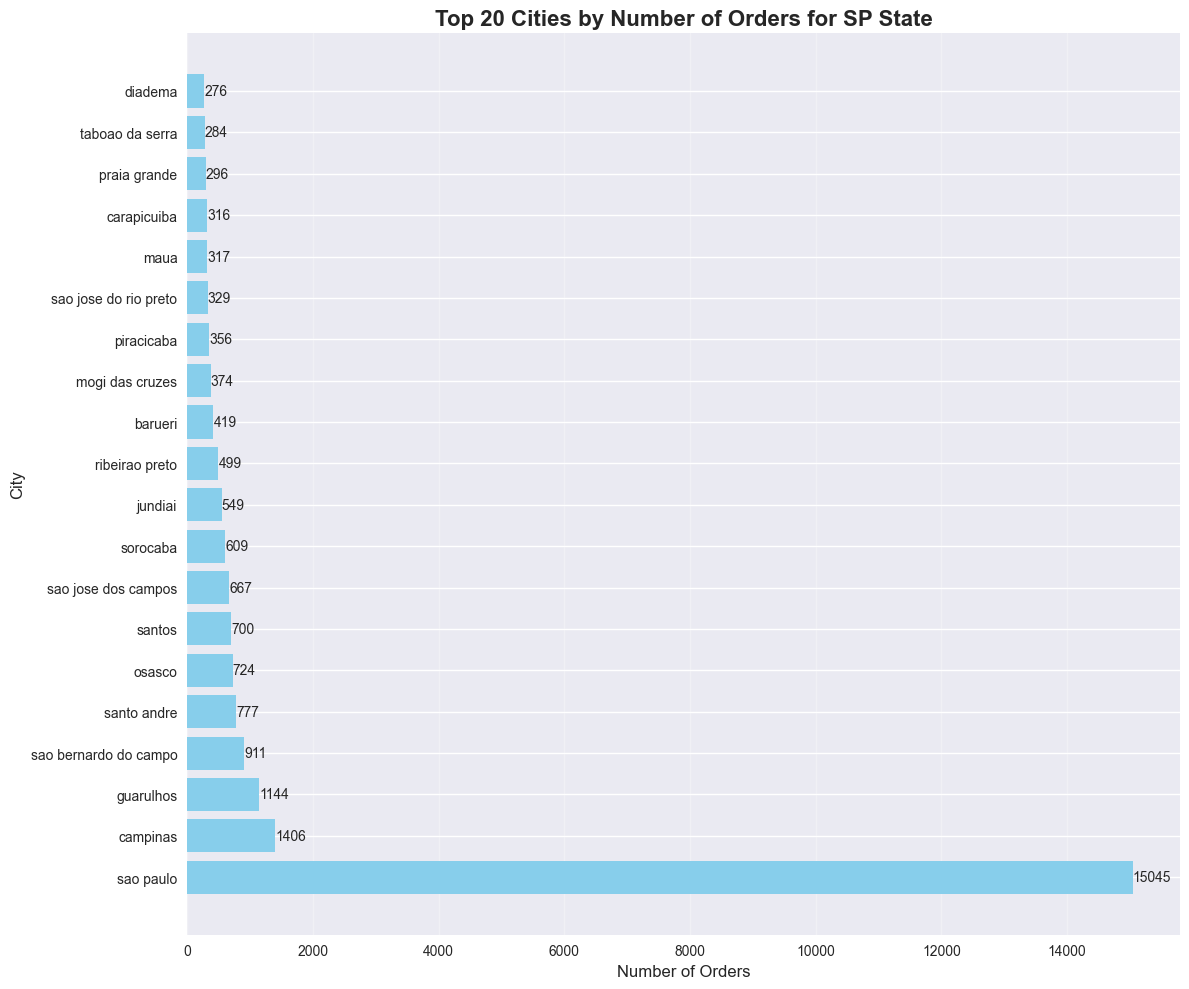

Top 20 cities by number of orders for SP state:
        customer_city  order_count
            sao paulo        15045
             campinas         1406
            guarulhos         1144
sao bernardo do campo          911
          santo andre          777
               osasco          724
               santos          700
  sao jose dos campos          667
             sorocaba          609
              jundiai          549
       ribeirao preto          499
              barueri          419
      mogi das cruzes          374
           piracicaba          356
sao jose do rio preto          329
                 maua          317
          carapicuiba          316
         praia grande          296
      taboao da serra          284
              diadema          276

Total orders for SP state: 25998


In [52]:
# Get total number of orders per city for SP state
orders_by_city = df[df['customer_state'] == 'SP'].groupby('customer_city').size().reset_index(name='order_count')

# Sort by order count descending and get top 20
orders_by_city = orders_by_city.sort_values('order_count', ascending=False).head(20)

# Create bar chart
plt.figure(figsize=(12, 10))
bars = plt.barh(orders_by_city['customer_city'], orders_by_city['order_count'], color='skyblue')
plt.title('Top 20 Cities by Number of Orders for SP State', fontsize=16, fontweight='bold')
plt.xlabel('Number of Orders', fontsize=12)
plt.ylabel('City', fontsize=12)
plt.grid(True, alpha=0.3, axis='x')

# Add value labels on bars
for i, (city, count) in enumerate(zip(orders_by_city['customer_city'], orders_by_city['order_count'])):
    plt.text(count + 1, i, str(count), va='center')

plt.tight_layout()
plt.show()

# Display the results
print("Top 20 cities by number of orders for SP state:")
print(orders_by_city.to_string(index=False))

# Total orders for SP state
print(f"\nTotal orders for SP state: {orders_by_city['order_count'].sum()}")




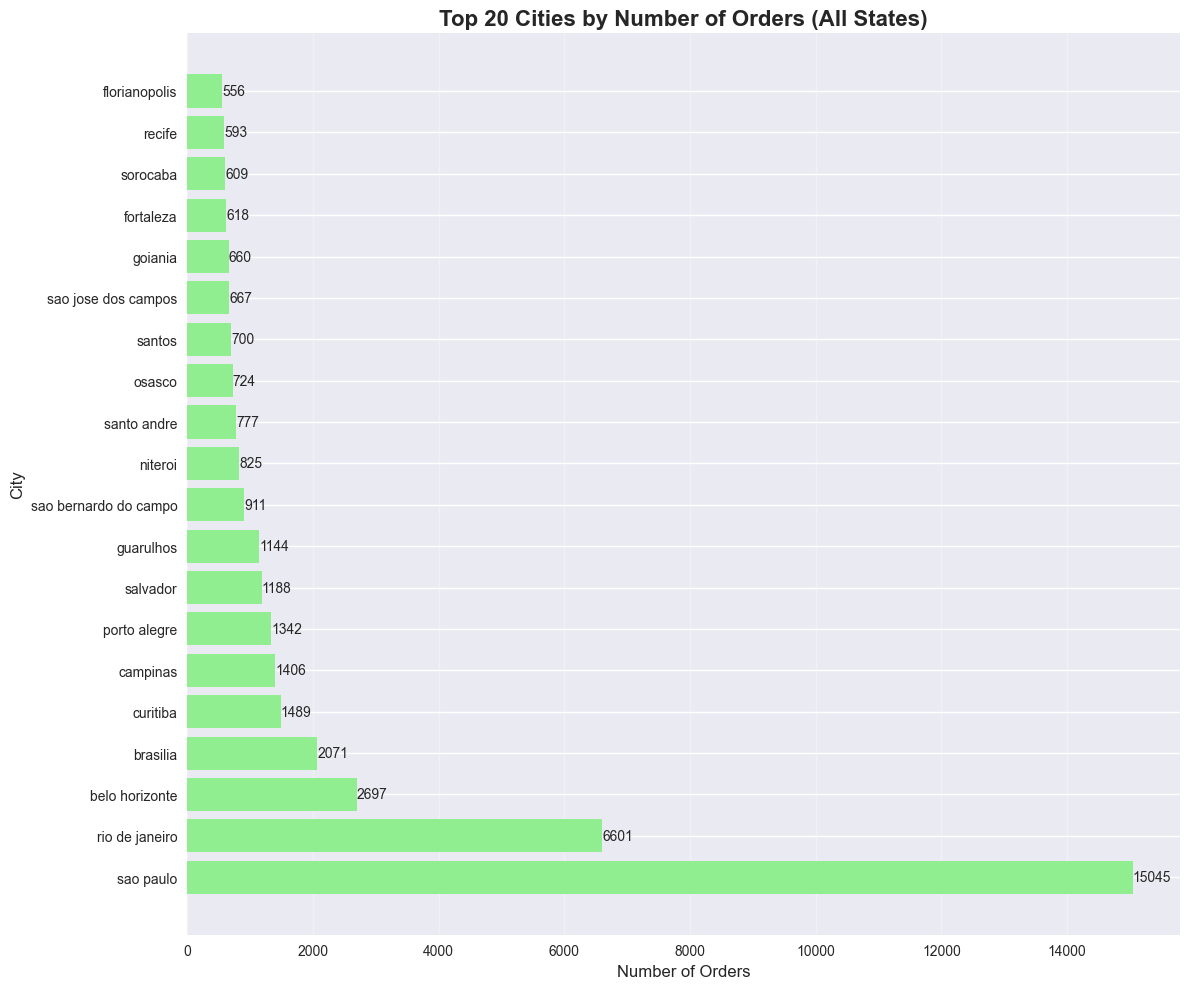

Top 20 cities by number of orders (All States):
customer_state         customer_city  order_count
            SP             sao paulo        15045
            RJ        rio de janeiro         6601
            MG        belo horizonte         2697
            DF              brasilia         2071
            PR              curitiba         1489
            SP              campinas         1406
            RS          porto alegre         1342
            BA              salvador         1188
            SP             guarulhos         1144
            SP sao bernardo do campo          911
            RJ               niteroi          825
            SP           santo andre          777
            SP                osasco          724
            SP                santos          700
            SP   sao jose dos campos          667
            GO               goiania          660
            CE             fortaleza          618
            SP              sorocaba          609
  

In [56]:
# Get total number of orders per city for all states
orders_by_city = df.groupby(['customer_state', 'customer_city']).size().reset_index(name='order_count')

# Sort by order count descending and get top 20
orders_by_city = orders_by_city.sort_values('order_count', ascending=False).head(20)

# Create bar chart
plt.figure(figsize=(12, 10))
bars = plt.barh(orders_by_city['customer_city'], orders_by_city['order_count'], color='lightgreen')
plt.title('Top 20 Cities by Number of Orders (All States)', fontsize=16, fontweight='bold')
plt.xlabel('Number of Orders', fontsize=12)
plt.ylabel('City', fontsize=12)
plt.grid(True, alpha=0.3, axis='x')

# Add value labels on bars
for i, (city, count) in enumerate(zip(orders_by_city['customer_city'], orders_by_city['order_count'])):
    plt.text(count + 1, i, str(count), va='center')

plt.tight_layout()
plt.show()

# Display the results
print("Top 20 cities by number of orders (All States):")
print(orders_by_city.to_string(index=False))

# Total orders for all states
print(f"\nTotal orders for all states: {orders_by_city['order_count'].sum()}")



In [58]:
%pip install streamlit

  Using cached altair-6.1.0-py3-none-any.whl.metadata (11 kB)
  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached pydeck-0.9.2-py2.py3-none-any.whl.metadata (4.2 kB)
  Using cached protobuf-7.34.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached tenacity-9.1.4-py3-none-any.whl.metadata (1.2 kB)
  Using cached toml-0.10.2-py2.py3-none-any.whl.metadata (7.1 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached anyio-4.13.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached watchdog-6.0.0-py3-none-win_amd64.whl.metadata (44 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached jsonschema-4.26.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached gitdb-4.0.12-py3-none-any.whl.metadata (1.2 kB)
  Using cached smmap-5.0.3-py3-none-any.whl.metadata (4.6 kB)
  Using cached charset_normalizer-3.4.7-cp314-cp314-win_amd64.whl.metadata (41 kB)
  Using cached certifi-2026.4.22-py3-none-any.whl.me


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [67]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Set page configuration
st.set_page_config(page_title="Brazilian E-commerce Analysis", layout="wide")

# Title
st.title("📊 Brazilian E-commerce Analysis Dashboard")

# Load data function
@st.cache_data
def load_data():
    file_path = r'C:\Users\camil\OneDrive\Escritorio\Proyecto_final_mod2\dataset_analitico.pkl'
    
    try:
        # Check if file exists
        if not os.path.exists(file_path):
            st.error(f"❌ File not found: {file_path}")
            st.info("Creating sample data for demonstration...")
            
            # Create sample data
            np.random.seed(42)
            states = ['SP', 'RJ', 'MG', 'RS', 'PR', 'SC', 'BA', 'CE', 'PE', 'GO']
            cities = ['São Paulo', 'Rio de Janeiro', 'Belo Horizonte', 'Porto Alegre', 'Curitiba', 
                     'Florianópolis', 'Salvador', 'Fortaleza', 'Recife', 'Goiânia']
            
            data = []
            for _ in range(1000):
                state = np.random.choice(states)
                city = np.random.choice(cities)
                data.append({'customer_state': state, 'customer_city': city})
            
            df = pd.DataFrame(data)
            st.success("✅ Sample data created successfully!")
            return df
        
        # Load the pickle file
        df = pd.read_pickle(file_path)
        st.success("✅ Data loaded successfully from file!")
        return df
        
    except Exception as e:
        st.error(f"❌ Error loading data: {str(e)}")
        st.info("Creating sample data for demonstration...")
        
        # Create sample data as fallback
        np.random.seed(42)
        states = ['SP', 'RJ', 'MG', 'RS', 'PR', 'SC', 'BA', 'CE', 'PE', 'GO']
        cities = ['São Paulo', 'Rio de Janeiro', 'Belo Horizonte', 'Porto Alegre', 'Curitiba', 
                 'Florianópolis', 'Salvador', 'Fortaleza', 'Recife', 'Goiânia']
        
        data = []
        for _ in range(1000):
            state = np.random.choice(states)
            city = np.random.choice(cities)
            data.append({'customer_state': state, 'customer_city': city})
        
        df = pd.DataFrame(data)
        st.success("✅ Sample data created successfully!")
        return df

# Load the data
df = load_data()

# Check if df is loaded properly
if df is None or df.empty:
    st.error("❌ No data available to display. Please check the file path or data source.")
    st.stop()

# Sidebar for filters
st.sidebar.header("Filters")

# Ensure the required columns exist
if 'customer_state' not in df.columns:
    st.error("❌ Required column 'customer_state' not found in data")
    st.stop()

if 'customer_city' not in df.columns:
    st.error("❌ Required column 'customer_city' not found in data")
    st.stop()

# Create sidebar filter
selected_state = st.sidebar.selectbox(
    "Select State", 
    ['All'] + list(df['customer_state'].unique())
)

# Filter data based on selection
if selected_state == 'All':
    filtered_df = df
else:
    filtered_df = df[df['customer_state'] == selected_state]

# Main content
st.header(f"Analysis for {selected_state if selected_state != 'All' else 'All States'}")

# Top 20 cities by order count
orders_by_city = filtered_df.groupby(['customer_state', 'customer_city']).size().reset_index(name='order_count')
orders_by_city = orders_by_city.sort_values('order_count', ascending=False).head(20)

# Create bar chart
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(orders_by_city['customer_city'], orders_by_city['order_count'], color='skyblue')
ax.set_xlabel('Number of Orders')
ax.set_ylabel('City')
ax.set_title(f'Top 20 Cities by Order Count ({selected_state if selected_state != "All" else "All States"})')
ax.invert_yaxis()  # Show highest at top

# Add value labels on bars
for i, (bar, count) in enumerate(zip(bars, orders_by_city['order_count'])):
    ax.text(count + 0.5, i, str(count), va='center')

plt.tight_layout()
st.pyplot(fig)

# Display table
st.subheader("Top 20 Cities by Order Count")
st.dataframe(orders_by_city.reset_index(drop=True))

# Total orders metric
total_orders = orders_by_city['order_count'].sum()
st.metric("Total Orders", f"{total_orders:,}")

# State-wise distribution
st.subheader("Orders by State")
state_orders = df.groupby('customer_state').size().sort_values(ascending=False)
st.bar_chart(state_orders)

# Data information
st.sidebar.markdown("---")
st.sidebar.subheader("Data Info")
st.sidebar.write(f"Total Records: {len(df):,}")
st.sidebar.write(f"Total States: {df['customer_state'].nunique()}")
st.sidebar.write(f"Total Cities: {df['customer_city'].nunique()}")


2026-05-18 20:13:06.269 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-18 20:13:06.270 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-18 20:13:06.270 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-18 20:13:06.270 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-18 20:13:06.271 No runtime found, using MemoryCacheStorageManager
2026-05-18 20:13:06.272 No runtime found, using MemoryCacheStorageManager
2026-05-18 20:13:06.272 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-18 20:13:06.275 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-18 20:13:06.276 Thread 'MainThread': missing ScriptRunContext! This warning can be ignor